# CEAS_08 Data Exploration

This notebook explores the raw CEAS_08 dataset without modifying it. Keep the raw CSV at `final_project/data/raw/CEAS_08.csv`. The EDA focuses on the fields needed for the offline phishing detection workflow.


## Load Dataset

Load the raw CSV and inspect the dataset shape.


In [1]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
if cwd.name == "final_project":
    PROJECT_ROOT = cwd
elif cwd.parent.name == "final_project":
    PROJECT_ROOT = cwd.parent
elif (cwd / "final_project").is_dir():
    PROJECT_ROOT = cwd / "final_project"
else:
    raise RuntimeError(f"Could not locate final_project from working directory: {cwd}")

sys.path.insert(0, str(PROJECT_ROOT))
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "CEAS_08.csv"
df = pd.read_csv(RAW_PATH)
df.shape


(39154, 7)

## Columns

Review the available columns before selecting the fields used by the phishing detection workflow.


In [2]:
df.columns.tolist()


['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

## Missing Values

Check missing values to understand what preprocessing must fill or validate.


In [3]:
df.isna().sum().sort_values(ascending=False)


receiver    462
subject      28
sender        0
date          0
body          0
label         0
urls          0
dtype: int64

## Label Distribution

Review the class balance between benign (`0`) and phishing/spam (`1`) labels.


In [4]:
label_counts = df["label"].value_counts(dropna=False).sort_index()
label_percent = (label_counts / len(df) * 100).round(2)
pd.DataFrame({"email_count": label_counts, "percent": label_percent})


,email_count,percent
label,,
0,17312,44.22
1,21842,55.78


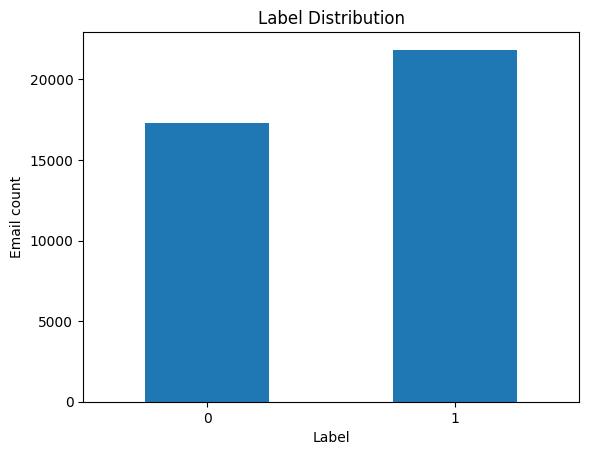

In [5]:
label_counts.plot(kind="bar", title="Label Distribution")
plt.xlabel("Label")
plt.ylabel("Email count")
plt.xticks(rotation=0)
plt.show()


## Text Length Distribution

Combine subject and body temporarily for exploration, then inspect text length statistics and outliers.


In [6]:
subject = df.get("subject", pd.Series("", index=df.index)).fillna("").astype(str)
body = df.get("body", pd.Series("", index=df.index)).fillna("").astype(str)
text = (subject + " " + body).str.strip()
text_lengths = text.str.len()
text_lengths.describe().round(2)


count     39154.00
mean       1608.26
std        3617.30
min          21.00
25%         257.25
50%         598.00
75%        1689.00
max      144051.00
dtype: float64

In [7]:
pd.DataFrame({
    "metric": ["empty_text", "over_10000_chars", "over_50000_chars"],
    "email_count": [
        int((text_lengths == 0).sum()),
        int((text_lengths > 10_000).sum()),
        int((text_lengths > 50_000).sum()),
    ],
})


,metric,email_count
0,empty_text,0
1,over_10000_chars,598
2,over_50000_chars,32


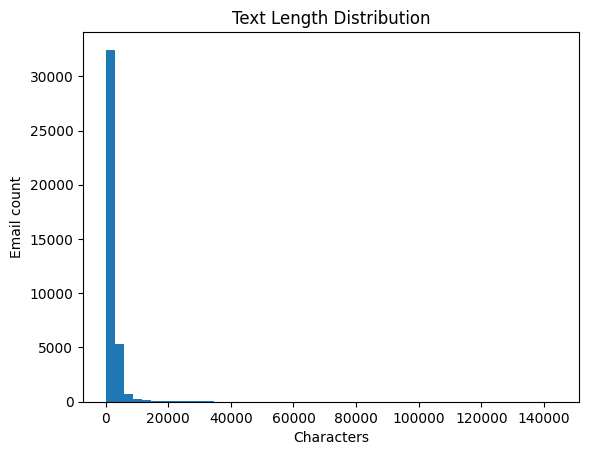

In [8]:
text_lengths.plot(kind="hist", bins=50, title="Text Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Email count")
plt.show()


## URL Indicator Distribution

The raw CEAS `urls` column is a binary URL indicator. Analyze it directly instead of using URL-count extraction.


In [9]:
url_indicator = pd.to_numeric(df["urls"], errors="coerce")
url_counts = url_indicator.value_counts(dropna=False).sort_index()
url_percent = (url_counts / len(df) * 100).round(2)
pd.DataFrame({"email_count": url_counts, "percent": url_percent})


,email_count,percent
urls,,
0,12922,33.0
1,26232,67.0


In [10]:
pd.crosstab(
    df["label"],
    url_indicator.fillna("missing"),
    rownames=["label"],
    colnames=["has_url"],
)


has_url,0,1
label,,
0,5969,11343
1,6953,14889


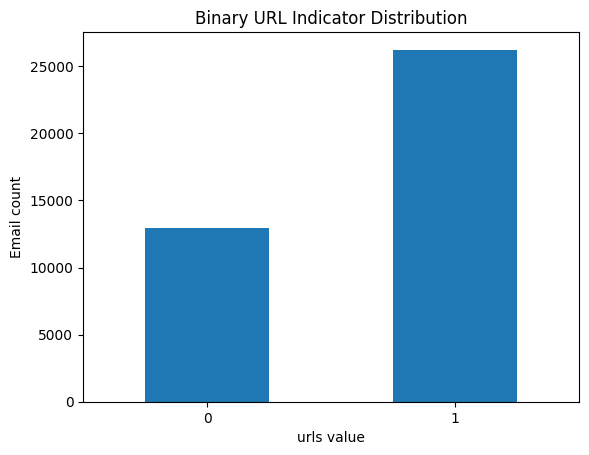

In [11]:
url_indicator.value_counts(dropna=False).sort_index().plot(kind="bar", title="Binary URL Indicator Distribution")
plt.xlabel("urls value")
plt.ylabel("Email count")
plt.xticks(rotation=0)
plt.show()


## Suspicious Token Patterns

Count common phishing-oriented terms in the combined subject and body text. These deterministic patterns can later inform indicator extraction, risk scoring, and demo explanations.


In [12]:
token_patterns = {
    "password": r"\bpasswords?\b",
    "verify": r"\bverify|verification|verified\b",
    "login": r"\blog[ -]?in|\bsign[ -]?in\b",
    "urgent": r"\burgent|immediately|limited time\b",
    "account": r"\baccounts?\b",
    "click": r"\bclick\b",
    "update": r"\bupdate|upgrade\b",
    "credential_language": r"\bcredentials?|username|user name|pin code|security code\b",
}

pattern_rows = []
for pattern_name, pattern in token_patterns.items():
    match_mask = text.str.contains(pattern, flags=re.IGNORECASE, regex=True, na=False)
    phishing_mask = df["label"] == 1
    benign_mask = df["label"] == 0
    total_matches = int(match_mask.sum())
    phishing_matches = int((match_mask & phishing_mask).sum())
    benign_matches = int((match_mask & benign_mask).sum())
    pattern_rows.append(
        {
            "pattern": pattern_name,
            "matching_emails": total_matches,
            "phishing_matches": phishing_matches,
            "benign_matches": benign_matches,
            "phishing_share_percent": round((phishing_matches / total_matches * 100), 2) if total_matches else 0.0,
        }
    )

pattern_summary = pd.DataFrame(pattern_rows).sort_values("matching_emails", ascending=False)
pattern_summary


,pattern,matching_emails,phishing_matches,benign_matches,phishing_share_percent
5,click,4054,2803,1251,69.14
6,update,3521,1297,2224,36.84
4,account,1287,307,980,23.85
3,urgent,674,224,450,33.23
1,verify,504,43,461,8.53
2,login,495,8,487,1.62
0,password,392,8,384,2.04
7,credential_language,256,4,252,1.56


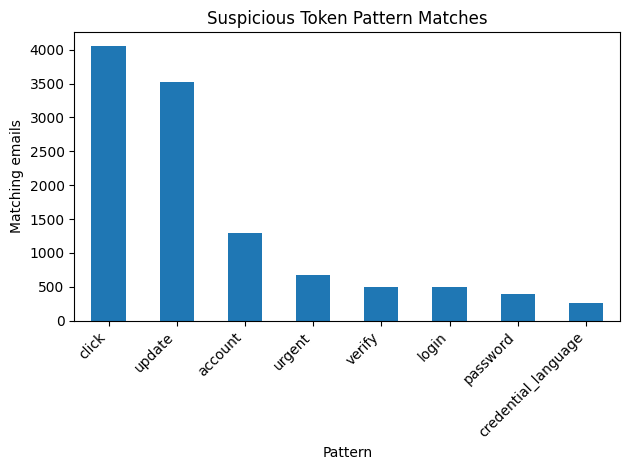

In [13]:
pattern_summary.set_index("pattern")["matching_emails"].plot(kind="bar", title="Suspicious Token Pattern Matches")
plt.xlabel("Pattern")
plt.ylabel("Matching emails")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## EDA Takeaways

The dataset is suitable for a simple explainable baseline. Preprocessing should keep label validation, subject/body normalization, binary URL handling, duplicate removal, and long-text trimming. Suspicious token counts are noisy but useful as deterministic evidence for later indicator extraction and risk explanations.
